In [1]:
import sqlite3
import pandas as pd
from pathlib import Path

data_dir = Path("../data")
conn = sqlite3.connect(data_dir / "olist.db")

files = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

for table, file in files.items():
    df = pd.read_csv(data_dir / file)
    df.to_sql(table, conn, if_exists="replace", index=False)
    print(f"{table}: {len(df):,} rows loaded")

orders: 99,441 rows loaded
customers: 99,441 rows loaded
order_items: 112,650 rows loaded
payments: 103,886 rows loaded
reviews: 99,224 rows loaded
products: 32,951 rows loaded
sellers: 3,095 rows loaded
category_translation: 71 rows loaded


In [2]:
query = """
SELECT
    COALESCE(t.product_category_name_english, p.product_category_name) AS category,
    ROUND(SUM(oi.price), 2) AS revenue,
    COUNT(DISTINCT oi.order_id) AS orders
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY revenue DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,category,revenue,orders
0,health_beauty,1233131.72,8647
1,watches_gifts,1166176.98,5495
2,bed_bath_table,1023434.76,9272
3,sports_leisure,954852.55,7530
4,computers_accessories,888724.61,6530
5,furniture_decor,711927.69,6307
6,housewares,615628.69,5743
7,cool_stuff,610204.10,3559
8,auto,578966.65,3810
9,toys,471286.48,3804


Top 10 categories = 62.4% of total revenue


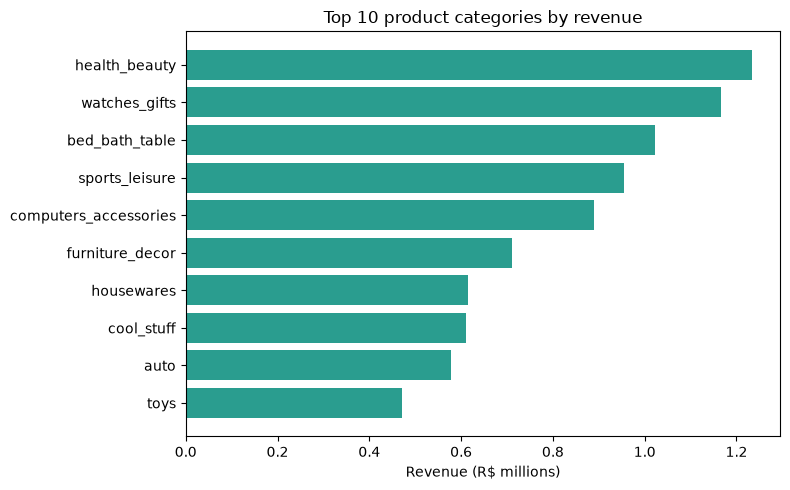

In [3]:
import matplotlib.pyplot as plt

top10 = pd.read_sql(query, conn)

total = pd.read_sql("""
    SELECT SUM(oi.price) AS total
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
""", conn)["total"][0]
print(f"Top 10 categories = {top10['revenue'].sum() / total:.1%} of total revenue")

plot_df = top10.sort_values("revenue")
plt.figure(figsize=(8, 5))
plt.barh(plot_df["category"], plot_df["revenue"] / 1e6, color="#2a9d8f")
plt.xlabel("Revenue (R$ millions)")
plt.title("Top 10 product categories by revenue")
plt.tight_layout()
plt.savefig("../dashboard/top_categories.png", dpi=150)
plt.show()

In [4]:
monthly_query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    COUNT(DISTINCT o.order_id) AS orders,
    ROUND(SUM(oi.price), 2) AS revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
  AND strftime('%Y-%m', o.order_purchase_timestamp) BETWEEN '2017-01' AND '2018-08'
GROUP BY month
ORDER BY month;
"""
monthly = pd.read_sql(monthly_query, conn)
print(monthly)

      month  orders    revenue
0   2017-01     750  111798.36
1   2017-02    1653  234223.40
2   2017-03    2546  359198.85
3   2017-04    2303  340669.68
4   2017-05    3546  489338.25
5   2017-06    3135  421923.37
6   2017-07    3872  481604.52
7   2017-08    4193  554699.70
8   2017-09    4150  607399.67
9   2017-10    4478  648247.65
10  2017-11    7289  987765.37
11  2017-12    5513  726033.19
12  2018-01    7069  924645.00
13  2018-02    6555  826437.13
14  2018-03    7003  953356.25
15  2018-04    6798  973534.09
16  2018-05    6749  977544.69
17  2018-06    6099  856077.86
18  2018-07    6159  867953.46
19  2018-08    6351  838576.64


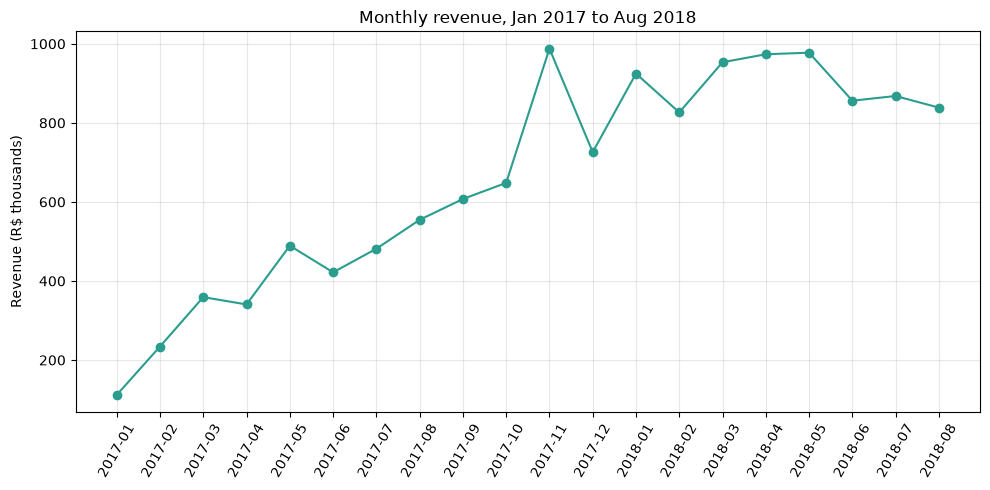

Peak month: 2017-11 | revenue: 987765.37


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly["month"], monthly["revenue"] / 1e3, marker="o", color="#2a9d8f")
plt.xticks(rotation=60)
plt.ylabel("Revenue (R$ thousands)")
plt.title("Monthly revenue, Jan 2017 to Aug 2018")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../dashboard/monthly_revenue.png", dpi=150)
plt.show()

peak = monthly.loc[monthly["revenue"].idxmax()]
print("Peak month:", peak["month"], "| revenue:", peak["revenue"])

In [6]:
repeat_query = """
SELECT
    orders_per_customer,
    COUNT(*) AS customers
FROM (
    SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS orders_per_customer
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
GROUP BY orders_per_customer
ORDER BY orders_per_customer;
"""
repeat = pd.read_sql(repeat_query, conn)
print(repeat)
print(f"Repeat customers: {repeat[repeat['orders_per_customer'] > 1]['customers'].sum() / repeat['customers'].sum():.1%}")

   orders_per_customer  customers
0                    1      90557
1                    2       2573
2                    3        181
3                    4         28
4                    5          9
5                    6          5
6                    7          3
7                    9          1
8                   15          1
Repeat customers: 3.0%


In [7]:
first_order_query = """
WITH cust_orders AS (
    SELECT c.customer_unique_id, o.order_id,
           ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id
                              ORDER BY o.order_purchase_timestamp) AS rn,
           COUNT(*) OVER (PARTITION BY c.customer_unique_id) AS n_orders
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),
first_orders AS (SELECT * FROM cust_orders WHERE rn = 1),
rev AS (SELECT order_id, AVG(review_score) AS score FROM reviews GROUP BY order_id)
SELECT ROUND(r.score) AS first_order_score,
       COUNT(*) AS customers,
       ROUND(100.0 * SUM(n_orders > 1) / COUNT(*), 2) AS repeat_pct
FROM first_orders f
JOIN rev r ON f.order_id = r.order_id
GROUP BY 1
ORDER BY 1;
"""
pd.read_sql(first_order_query, conn)

,first_order_score,customers,repeat_pct
0,1.0,9062,2.75
1,2.0,2834,2.79
2,3.0,7683,2.99
3,4.0,18365,2.78
4,5.0,54797,3.12


In [11]:
first_order_query = """
WITH cust_orders AS (
    SELECT c.customer_unique_id, o.order_id,
           ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id
                              ORDER BY o.order_purchase_timestamp) AS rn,
           COUNT(*) OVER (PARTITION BY c.customer_unique_id) AS n_orders
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),
first_orders AS (SELECT * FROM cust_orders WHERE rn = 1),
rev AS (SELECT order_id, AVG(review_score) AS score FROM reviews GROUP BY order_id)
SELECT ROUND(r.score) AS first_order_score,
       COUNT(*) AS customers,
       ROUND(100.0 * SUM(n_orders > 1) / COUNT(*), 2) AS repeat_pct
FROM first_orders f
JOIN rev r ON f.order_id = r.order_id
GROUP BY 1
ORDER BY 1;
"""
pd.read_sql(first_order_query, conn)

,first_order_score,customers,repeat_pct
0,1.0,9062,2.75
1,2.0,2834,2.79
2,3.0,7683,2.99
3,4.0,18365,2.78
4,5.0,54797,3.12


In [12]:
total = pd.read_sql("""
    SELECT SUM(oi.price) AS total
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
""", conn)["total"][0]
top10 = pd.read_sql(query, conn)
print(f"Top 10 categories = {top10['revenue'].sum() / total:.1%} of total revenue")

Top 10 categories = 62.4% of total revenue
